# Chapter 8g — Palaeoclimate Records and the Scientific Consensus

This notebook closes out Chapter 8 Part 1, moving from the deep-time
geological record (carbon-isotope excursions hundreds of millions of years
old, Antarctic ice cores spanning 420,000 years, a 66-million-year CO$_2$
reconstruction) up to the instrumental era (the Keeling Curve since 1958),
and closing with two bibliometric surveys of the climate-science research
community itself.

One near-duplicate institutional breakdown is skipped: a second
country-tabulation view that just re-exports the same country-breakdown
numbers already shown in section 6 to a spreadsheet with no new content
isn't rebuilt as a separate section here (the same skip policy applied to
near-duplicate exercises in Chapter 6).

**Real data used:** carbon-isotope compilations from Cox et al. and a PMC
supplementary dataset (Neoproterozoic "Snowball Earth" excursions), the
Vostok, Antarctica ice core (Petit et al. 1999), Foster et al.'s
66-million-year LOESS-smoothed CO$_2$ reconstruction, NOAA's Mauna Loa
Keeling Curve record, and two published academic bibliometric datasets — a
"Highly Cited Researchers" climate-science hot list and the Nature Index
2016-2023 institutional rankings — all shipped as spreadsheets in this
project's `Data/` folder.


In [1]:

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from csaps import csaps

# The shipped chap8_palaeoclimate_cox.xlsx contains an Excel print-area
# extension openpyxl doesn't recognize; harmless, but silence it so it
# doesn't show up as a spurious notebook warning.
warnings.filterwarnings("ignore", message="Unknown extension is not supported", module="openpyxl")

DATA_DIR = "../../data"

color_blue    = np.array([  0,  20, 255]) / 255
color_red     = np.array([255,  80,  50]) / 255
color_green   = np.array([ 20, 200,  80]) / 255
color_violet  = np.array([255,  51, 255]) / 255
color_teal    = np.array([ 56, 142, 142]) / 255
color_coral   = np.array([255, 127,  80]) / 255
color_black   = np.array([0, 0, 0])

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 40)


## 1. Neoproterozoic carbon-isotope excursions

Large swings in $\delta^{13}\mathrm{C}$ (the ratio of carbon-13 to
carbon-12 in marine carbonate rock, relative to a standard) are one of the
main lines of geological evidence for the Neoproterozoic "Snowball Earth"
glaciations modeled in `08c` — a large negative excursion indicates a
collapse in biological productivity consistent with a globally
ice-covered ocean. The first chart below looks at ~0-4,000 million-year-old
(Ma) samples split by mineral type; the second zooms into the 500-1,050 Ma
window (the actual Snowball Earth interval) across nine geological
sampling locations worldwide.


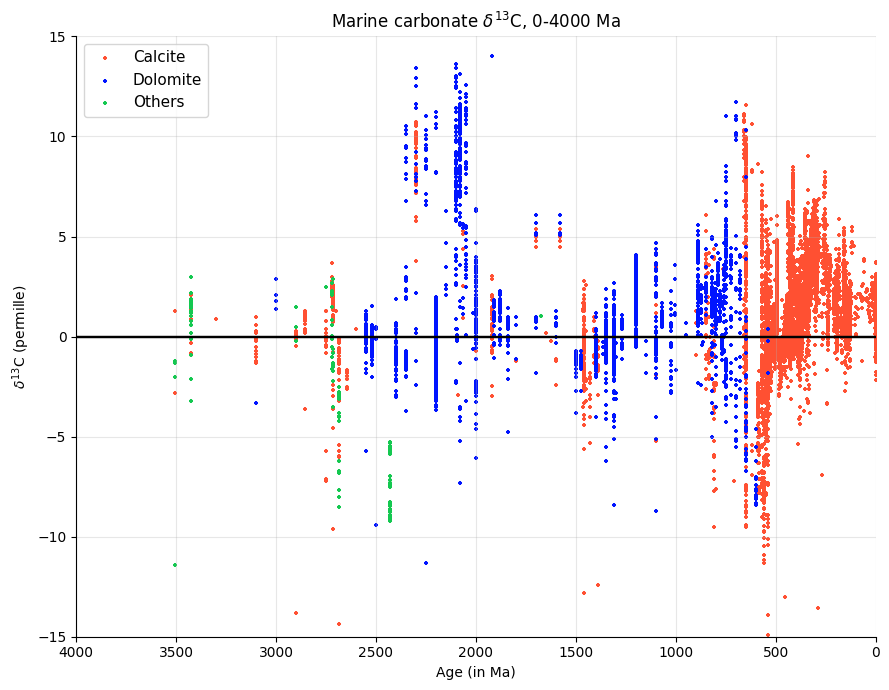

In [2]:

pmcid = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_pmcid.xls", sheet_name="1.a")
for c in ["Age (Ma)", "Age (Ma).1", "d13Ccalcite PDB", "d13Cdolomite PDB", "d13Cothers PDB"]:
    pmcid[c] = pd.to_numeric(pmcid[c], errors="coerce")

fig, ax = plt.subplots(figsize=(9, 7))
series = [
    ("Age (Ma)", "d13Ccalcite PDB", "Calcite", color_red),
    ("Age (Ma).1", "d13Cdolomite PDB", "Dolomite", color_blue),
    ("Age (Ma)", "d13Cothers PDB", "Others", color_green),
]
for xcol, ycol, label, c in series:
    sub = pmcid[[xcol, ycol]].dropna()
    ax.scatter(sub[xcol], sub[ycol], s=10, marker="+", color=c, label=label)
ax.axhline(0, color=color_black, linewidth=1.75)

ax.set_xlim(4000, 0)
ax.set_ylim(-15, 15)
ax.set_xlabel("Age (in Ma)")
ax.set_ylabel(r"$\delta^{13}\mathrm{C}$ (permille)")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", fontsize=11)
ax.set_title(r"Marine carbonate $\delta^{13}\mathrm{C}$, 0-4000 Ma")
plt.tight_layout()
plt.show()


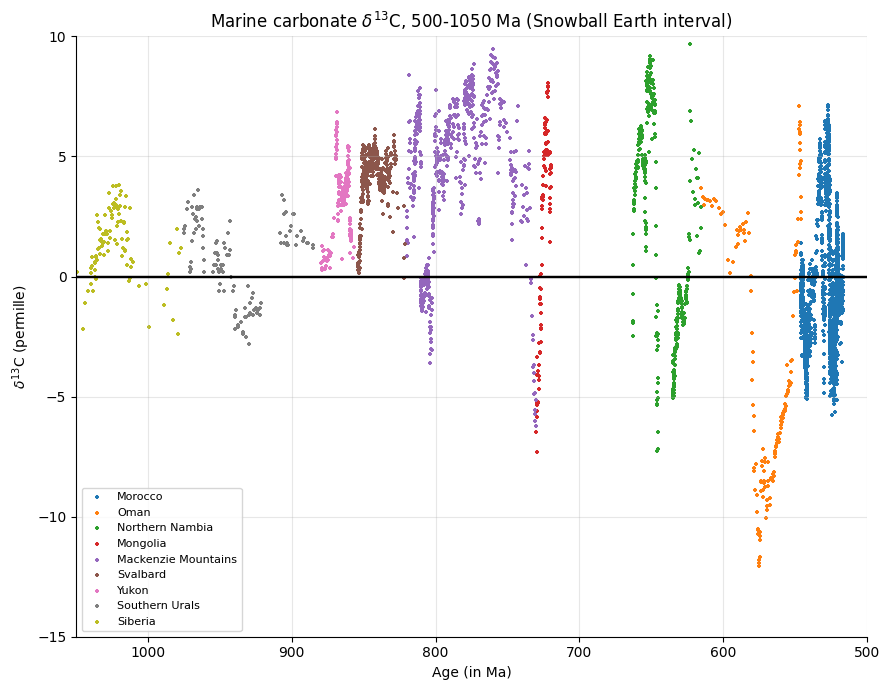

In [3]:

cox = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_cox.xlsx", header=1)
cox["Model age"] = pd.to_numeric(cox["Model age"], errors="coerce")
cox["δ13Ccarb"] = pd.to_numeric(cox["δ13Ccarb"], errors="coerce")

regions = ["Morocco", "Oman", "Nambia", "Mackenzies", "Svalbard", "NW Canada", "Ogilvie Mts", "S. Urals", "Turukhansk"]
region_labels = ["Morocco", "Oman", "Northern Nambia", "Mongolia", "Mackenzie Mountains",
                  "Svalbard", "Yukon", "Southern Urals", "Siberia"]
colors9 = plt.get_cmap("tab10").colors + (color_teal,)

fig, ax = plt.subplots(figsize=(9, 7))
for region, label, c in zip(regions, region_labels, colors9):
    sub = cox[cox["Location"] == region]
    ax.scatter(sub["Model age"], sub["δ13Ccarb"], s=10, marker="+", color=c, label=label)
ax.axhline(0, color=color_black, linewidth=1.75)

ax.set_xlim(1050, 500)
ax.set_ylim(-15, 10)
ax.set_xlabel("Age (in Ma)")
ax.set_ylabel(r"$\delta^{13}\mathrm{C}$ (permille)")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="lower left", fontsize=8)
ax.set_title(r"Marine carbonate $\delta^{13}\mathrm{C}$, 500-1050 Ma (Snowball Earth interval)")
plt.tight_layout()
plt.show()


## 2. The Vostok ice core, Antarctica

The Vostok ice core (Petit et al., 1999) is one of the classic
paleoclimate records: 420,000 years of trapped air bubbles and isotope
ratios preserved in Antarctic ice, showing four glacial-interglacial
cycles. The first panel below calibrates a deuterium-to-temperature
conversion; the second applies it across the full record; the third adds
the CH$_4$ and CO$_2$ trapped-gas records alongside the oxygen-isotope
record — all three greenhouse-gas-vs-temperature series moving together
is itself direct evidence for the feedback loops modeled abstractly in
`08b`.


Calibration: deltaT = 78.2776 + 0.179524 * deltaD


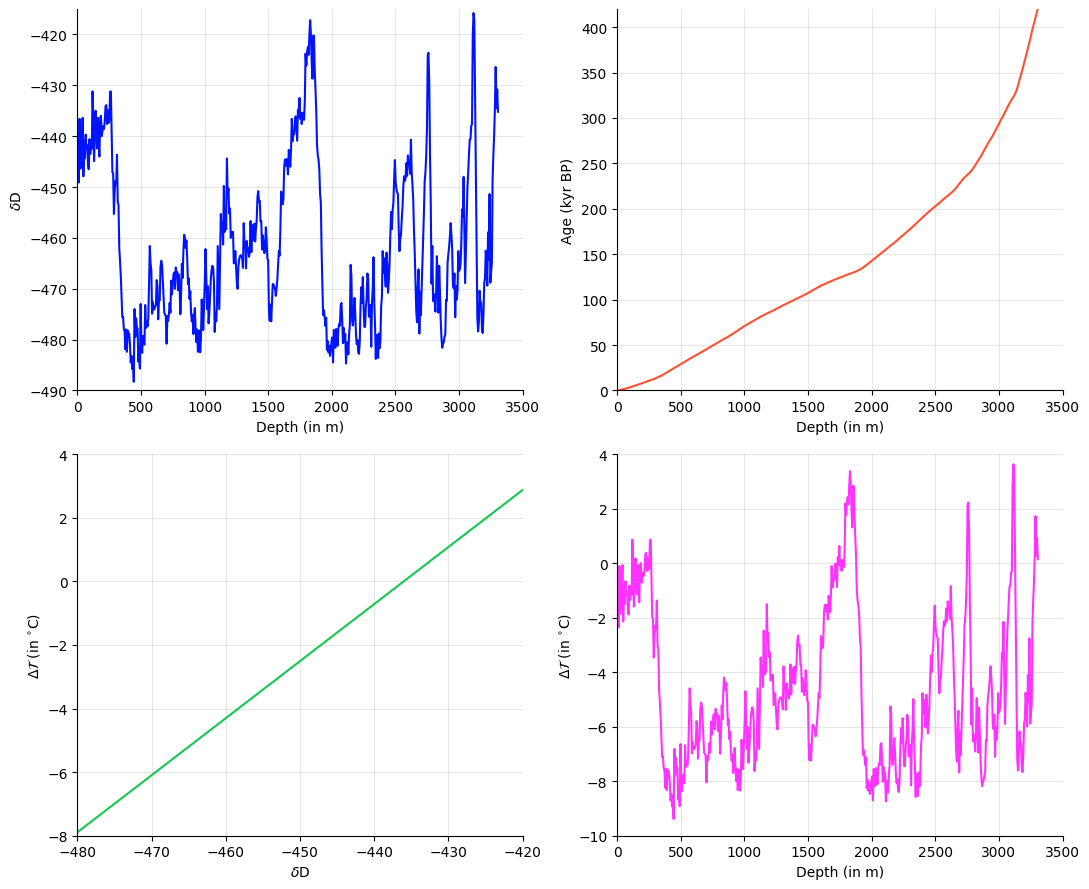

In [4]:

vostok_d = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_vostok_petit.xlsx", sheet_name="Deuterium")
vostok_d = vostok_d.iloc[::6].reset_index(drop=True)   # keep every 6th sample

depth_m = vostok_d["depth_m"].to_numpy()
ice_age = vostok_d["ice_ageBP"].to_numpy()
deltaD = vostok_d["deltaD"].to_numpy()

# Panel 3: deltaT = beta0 + beta1 * deltaD, calibrated by OLS against the deltaTS column
deltaTS = vostok_d["deltaTS"].to_numpy()
mask = ~np.isnan(deltaD) & ~np.isnan(deltaTS)
beta1, beta0 = np.polyfit(deltaD[mask], deltaTS[mask], 1)
print(f"Calibration: deltaT = {beta0:.4f} + {beta1:.6f} * deltaD")

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].plot(depth_m, deltaD, "-", color=color_blue, linewidth=1.5)
axes[0, 0].set_xlabel("Depth (in m)"); axes[0, 0].set_ylabel(r"$\delta\mathrm{D}$")
axes[0, 0].set_xlim(0, 3500); axes[0, 0].set_ylim(-490, -415)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(depth_m, ice_age / 1000, "-", color=color_red, linewidth=1.5)
axes[0, 1].set_xlabel("Depth (in m)"); axes[0, 1].set_ylabel("Age (kyr BP)")
axes[0, 1].set_xlim(0, 3500); axes[0, 1].set_ylim(0, 420)
axes[0, 1].grid(True, alpha=0.3)

x_cal = np.arange(-500, -399, 1)
y_cal = beta0 + beta1 * x_cal
axes[1, 0].plot(x_cal, y_cal, "-", color=color_green, linewidth=1.5)
axes[1, 0].set_xlabel(r"$\delta\mathrm{D}$"); axes[1, 0].set_ylabel(r"$\Delta\mathcal{T}$ (in $^{\circ}$C)")
axes[1, 0].set_xlim(-480, -420); axes[1, 0].set_ylim(-8, 4)
axes[1, 0].grid(True, alpha=0.3)

deltaT_full = beta0 + beta1 * deltaD
axes[1, 1].plot(depth_m, deltaT_full, "-", color=color_violet, linewidth=1.5)
axes[1, 1].set_xlabel("Depth (in m)"); axes[1, 1].set_ylabel(r"$\Delta\mathcal{T}$ (in $^{\circ}$C)")
axes[1, 1].set_xlim(0, 3500); axes[1, 1].set_ylim(-10, 4)
axes[1, 1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


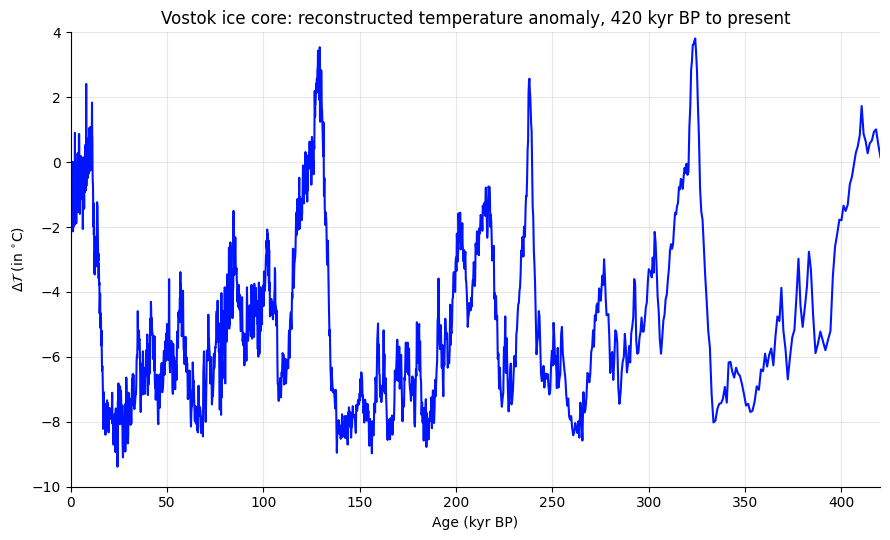

In [5]:

vostok_d2 = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_vostok_petit.xlsx", sheet_name="Deuterium")
vostok_d2 = vostok_d2.iloc[::2].reset_index(drop=True)   # keep every 2nd sample
deltaT2 = beta0 + beta1 * vostok_d2["deltaD"].to_numpy()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(vostok_d2["ice_ageBP"] / 1000, deltaT2, "-", color=color_blue, linewidth=1.5)
ax.set_xlabel("Age (kyr BP)"); ax.set_ylabel(r"$\Delta\mathcal{T}$ (in $^{\circ}$C)")
ax.set_xlim(0, 420); ax.set_ylim(-10, 4)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_title("Vostok ice core: reconstructed temperature anomaly, 420 kyr BP to present")
plt.tight_layout()
plt.show()


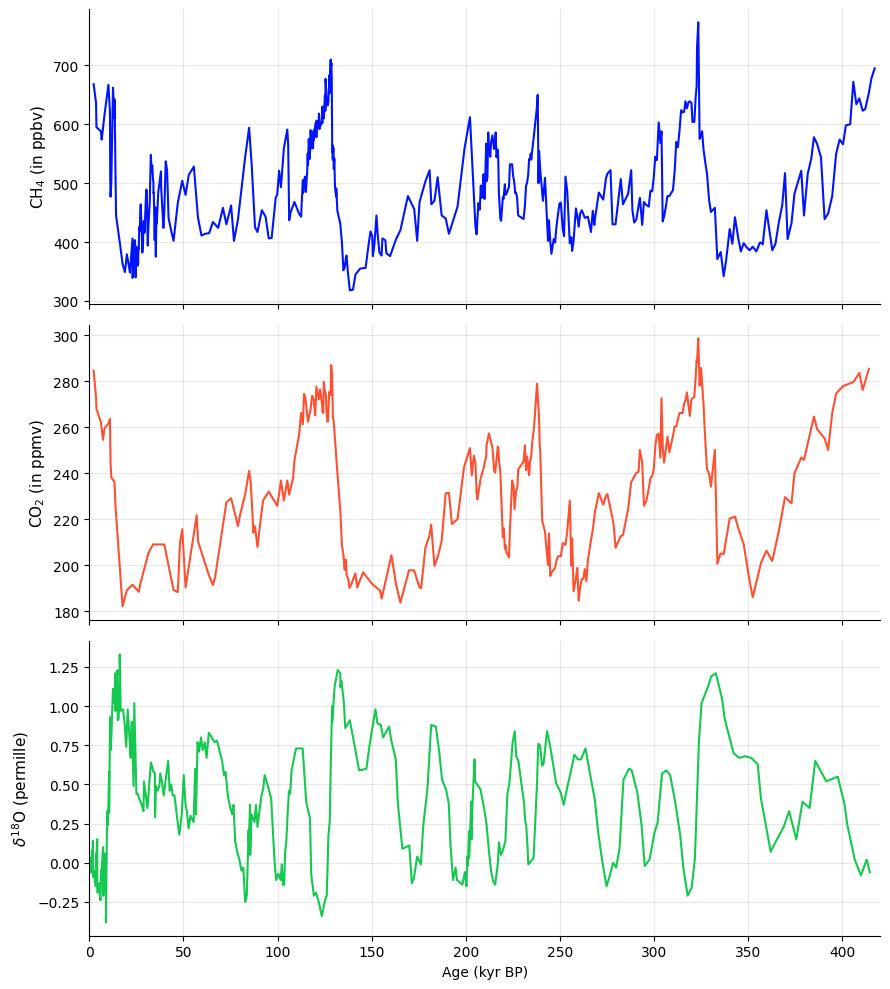

In [6]:

ch4 = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_vostok_petit.xlsx", sheet_name="CH4")
co2 = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_vostok_petit.xlsx", sheet_name="CO2")
o18 = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_vostok_petit.xlsx", sheet_name="O18")

panels = [
    (ch4, "gas_ageBP", "CH4", r"CH$_4$ (in ppbv)", color_blue),
    (co2, "gas_ageBP", "CO2", r"CO$_2$ (in ppmv)", color_red),
    (o18, "gas_ageBP", "atm_O18", r"$\delta^{18}\mathrm{O}$ (permille)", color_green),
]

fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
for ax, (df, xcol, ycol, ylabel, c) in zip(axes, panels):
    ax.plot(df[xcol] / 1000, df[ycol], "-", color=c, linewidth=1.5)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xlim(0, 420)
    ax.grid(True, which="both", alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
axes[-1].set_xlabel("Age (kyr BP)")

plt.tight_layout()
plt.show()


## 3. Deep ocean vs. surface air temperature, and "Hothouse"/"Icehouse" Earth

A purely illustrative (no external data) piecewise-linear conceptual
model relating benthic $\delta^{18}\mathrm{O}$ to deep-ocean temperature,
and deep-ocean to surface-air temperature, spanning the full range from
"Icehouse Earth" (ice ages) to "Hothouse Earth" (the warmest past climate
states) — with the Last Glacial Maximum (LGM, ~21,000 years ago) marked
for reference.


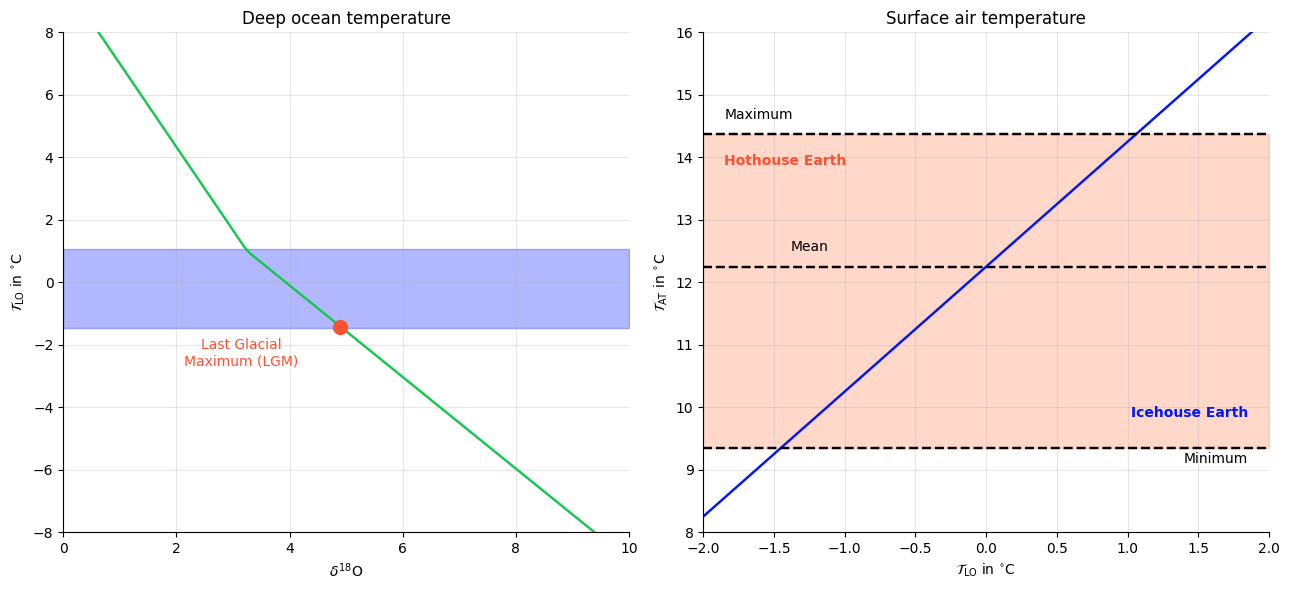

In [7]:

x = np.arange(0, 10.1, 0.1)
e = x < 3.25
y1_line = 5 - 8 * (x - 1.75) / 3
y2_line = 1 - 4.4 * (x - 3.25) / 3
y = np.where(e, y1_line, y2_line)

x_lgm = 4.9
y_lgm = 1 - 4.4 * (x_lgm - 3.25) / 3
y_lower, y_upper = -1.45, 1.06

T_LO = np.arange(-2, 2.01, 0.04)
T_mean = 12.25
T_AT = 2 * T_LO + T_mean
T_lower = 2 * y_lower + T_mean
T_upper = 2 * y_upper + T_mean

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.plot(x, y, "-", color=color_green, linewidth=1.75)
ax.fill_between([0, 10], y_lower, y_upper, color=color_blue, alpha=0.30)
ax.scatter([x_lgm], [y_lgm], s=100, color=color_red, zorder=5)
ax.annotate("Last Glacial\nMaximum (LGM)", xy=(x_lgm - 1.75, y_lgm - 1.25), color=color_red,
            ha="center", fontsize=10)
ax.set_xlabel(r"$\delta^{18}\mathrm{O}$"); ax.set_ylabel(r"$\mathcal{T}_\mathrm{LO}$ in $^{\circ}$C")
ax.set_title("Deep ocean temperature", fontsize=12)
ax.set_xlim(0, 10); ax.set_ylim(-8, 8)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

ax = axes[1]
ax.plot(T_LO, T_AT, "-", color=color_blue, linewidth=1.75)
ax.fill_between(T_LO, T_lower, T_upper, color=color_coral, alpha=0.30)
ax.axhline(T_mean, linestyle="--", color=color_black, linewidth=1.75)
ax.axhline(T_lower, linestyle="--", color=color_black, linewidth=1.75)
ax.axhline(T_upper, linestyle="--", color=color_black, linewidth=1.75)
ax.annotate("Mean", xy=(-1.25, T_mean + 0.25), ha="center", fontsize=10)
ax.annotate("Maximum", xy=(-1.85, T_upper + 0.25), ha="left", fontsize=10)
ax.annotate("Hothouse Earth", xy=(-1.85, T_upper - 0.5), ha="left", fontsize=10, color=color_red, fontweight="bold")
ax.annotate("Minimum", xy=(1.85, T_lower - 0.25), ha="right", fontsize=10)
ax.annotate("Icehouse Earth", xy=(1.85, T_lower + 0.5), ha="right", fontsize=10, color=color_blue, fontweight="bold")
ax.set_xlabel(r"$\mathcal{T}_\mathrm{LO}$ in $^{\circ}$C"); ax.set_ylabel(r"$\mathcal{T}_\mathrm{AT}$ in $^{\circ}$C")
ax.set_title("Surface air temperature", fontsize=12)
ax.set_xlim(-2, 2); ax.set_ylim(8, 16)
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 4. 66 million years of atmospheric CO$_2$

Foster, Royer & Lunt (2017) compiled hundreds of independent CO$_2$ proxy
records spanning the entire Cenozoic era and fit a LOESS (locally
weighted smoothing) curve through them, with 68% and 95% confidence
bands. Today's ~420 ppm is well outside anything the planet has seen in
the last several million years, and CO$_2$ levels this high were last
sustained around 14-16 million years ago.


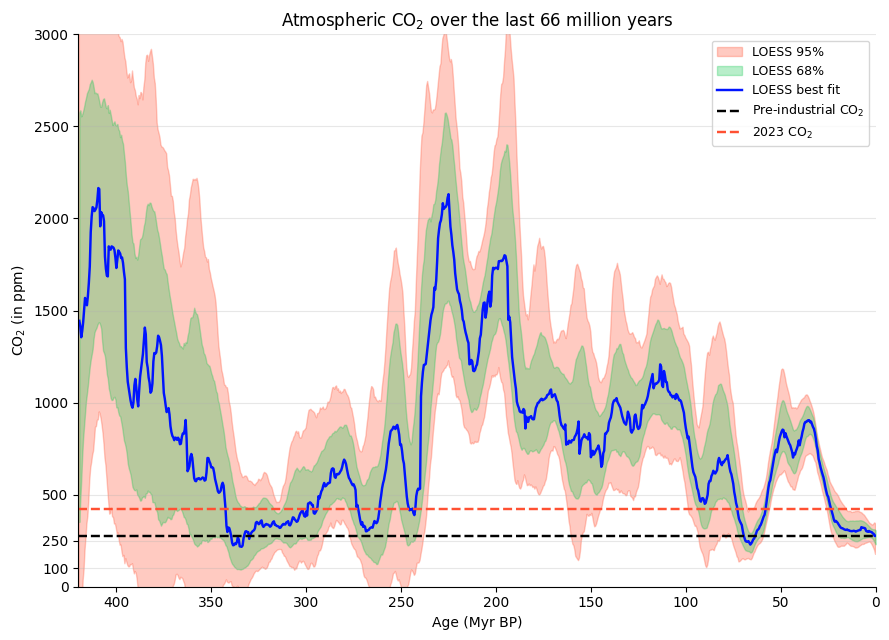

In [8]:

loess = pd.read_excel(f"{DATA_DIR}/chap8_palaeoclimate_loess_foster.xlsx", header=1)

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.fill_between(loess["Age (Ma)"], loess["lw95%"], loess["up95%"], color=color_red, alpha=0.30, label="LOESS 95%")
ax.fill_between(loess["Age (Ma)"], loess["lw68%"], loess["up68%"], color=color_green, alpha=0.30, label="LOESS 68%")
ax.plot(loess["Age (Ma)"], loess["pCO2 probability maximum"], "-", color=color_blue, linewidth=1.75, label="LOESS best fit")
ax.axhline(278, linestyle="--", color=color_black, linewidth=1.75, label="Pre-industrial CO$_2$")
ax.axhline(420, linestyle="--", color=color_red, linewidth=1.75, label="2023 CO$_2$")

ax.set_xlim(420, 0)
ax.set_yscale("linear")
ax.set_ylim(0, 3000)
ax.set_yticks([0, 100, 250, 500, 1000, 1500, 2000, 2500, 3000])
ax.set_xlabel("Age (Myr BP)"); ax.set_ylabel("CO$_2$ (in ppm)")
ax.grid(True, axis="y", alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", fontsize=9)
ax.set_title("Atmospheric CO$_2$ over the last 66 million years")
plt.tight_layout()
plt.show()


## 5. The Keeling Curve

The single most iconic climate-science figure: continuous monthly
CO$_2$ measurements at Mauna Loa Observatory, Hawaii, since 1958. The
inset shows the characteristic seasonal sawtooth (Northern Hemisphere
summer photosynthesis draws CO$_2$ down, winter decay releases it back)
riding on top of the relentless upward trend from ~315 ppm to over 420 ppm.

**Data-fidelity note:** the raw spreadsheet's exact column-to-series
mapping isn't documented, so it's identified empirically here: reading
the raw NOAA-format spreadsheet directly and checking each candidate
pairing's amplitude against the well-known ~3 ppm Keeling seasonal cycle
(see the check below) identifies the "CO2" column as the raw monthly
average (with its natural early-year gaps, shown as scattered points) and
"seasonally adjusted" as the deseasonalized trend — the standard and most
visually informative Keeling Curve pairing, and the one that reproduces
the record's well-known shape.


In [9]:

# Column-identification check: CO2 minus its correctly-paired deseasonalized
# column should have a standard deviation close to the Keeling Curve's known
# ~2 ppm seasonal-cycle amplitude (peak-to-peak ~5-6 ppm at Mauna Loa).
_check = pd.read_excel(f"{DATA_DIR}/chap8_Keeling_Curve_2023.xlsx", sheet_name="Keeling curve", header=None)
_check.columns = ["Yr", "Mn", "Date", "DateDec", "CO2", "CO2_deseasonalized", "fit", "fit_deseasonalized",
                   "CO2_filled", "CO2_deseasonalized_filled", "Station"]
_check = _check.iloc[3:].reset_index(drop=True)
for c in ["CO2", "CO2_deseasonalized", "fit", "fit_deseasonalized"]:
    _check[c] = pd.to_numeric(_check[c], errors="coerce")
print("std(CO2 - CO2_deseasonalized) =", round((_check['CO2'] - _check['CO2_deseasonalized']).std(), 3), "ppm  <- correct pairing")
print("std(CO2 - fit)                =", round((_check['CO2'] - _check['fit']).std(), 3), "ppm  <- 'fit' already includes the seasonal cycle")


std(CO2 - CO2_deseasonalized) = 2.109 ppm  <- correct pairing
std(CO2 - fit)                = 0.27 ppm  <- 'fit' already includes the seasonal cycle


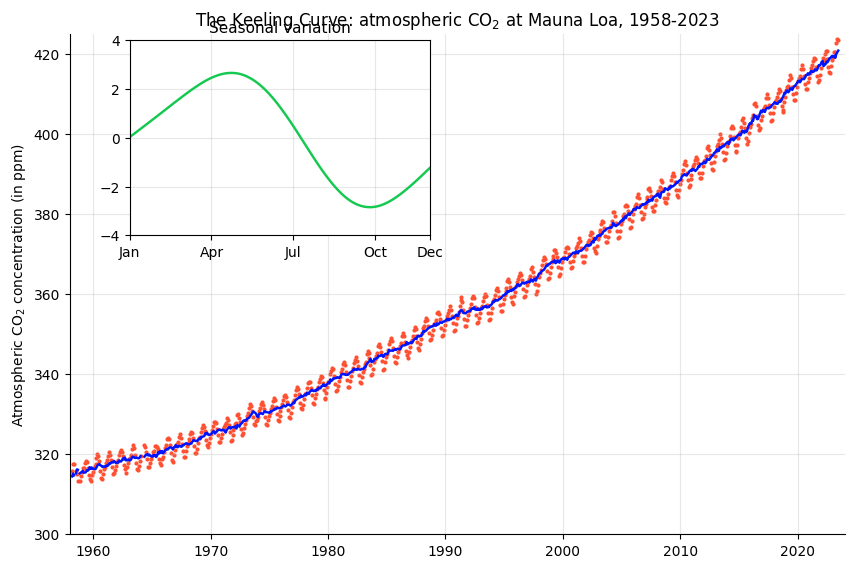

In [10]:

keeling = pd.read_excel(f"{DATA_DIR}/chap8_Keeling_Curve_2023.xlsx", sheet_name="Keeling curve", header=None)
keeling.columns = ["Yr", "Mn", "Date", "DateDec", "CO2", "CO2_deseasonalized", "fit", "fit_deseasonalized",
                    "CO2_filled", "CO2_deseasonalized_filled", "Station"]
keeling = keeling.iloc[3:].reset_index(drop=True)
for c in ["Yr", "Mn", "DateDec", "CO2", "CO2_deseasonalized", "fit", "fit_deseasonalized", "CO2_filled", "CO2_deseasonalized_filled"]:
    keeling[c] = pd.to_numeric(keeling[c], errors="coerce")
keeling["Date"] = pd.to_datetime(keeling["Date"])

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(keeling["Date"], keeling["CO2"], s=4, color=color_red)
ax.plot(keeling["Date"], keeling["CO2_deseasonalized"], "-", color=color_blue, linewidth=1.75)
ax.set_ylabel("Atmospheric CO$_2$ concentration (in ppm)")
ax.set_xlim(pd.Timestamp("1958-01-01"), pd.Timestamp("2023-12-31"))
ax.set_ylim(300, 425)
ax.grid(True, which="both", alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.set_title("The Keeling Curve: atmospheric CO$_2$ at Mauna Loa, 1958-2023")

seasonal_dev = (keeling["CO2"] - keeling["CO2_deseasonalized"]).to_numpy()
months = keeling["Mn"].to_numpy()
month_means = np.array([np.nanmean(seasonal_dev[months == m]) for m in range(1, 13)])
x_s2 = np.arange(1, 12.01, 0.1)
y_s2 = csaps(np.arange(1, 13), month_means, x_s2, smooth=0.5)

ax_inset = fig.add_axes([0.185, 0.57, 0.30, 0.30])
ax_inset.plot(x_s2, y_s2, "-", color=color_green, linewidth=1.75)
ax_inset.set_title("Seasonal variation", fontsize=11)
ax_inset.set_xlim(1, 12); ax_inset.set_xticks([1, 4, 7, 10, 12])
ax_inset.set_xticklabels(["Jan", "Apr", "Jul", "Oct", "Dec"])
ax_inset.set_ylim(-4, 4)
ax_inset.grid(True, alpha=0.3)

plt.show()


## 6. Who studies climate change? The 2021 Highly Cited Researchers hot list

A published bibliometric ranking (Reuters' 2021 climate "Hot List",
based on citation counts) of the 1,000 most-cited climate researchers
worldwide, with their institution and country.


In [11]:

hotlist = pd.read_excel(f"{DATA_DIR}/chap8_hotlist_2021.xlsx")

named_researchers = ["Philippe Ciais", "Gerald A Meehl", "Pete Smith", "Richard A Houghton", "Richard S J Tol",
                      "William D Nordhaus", "Phil D Jones*", "Filippo Giorgi", "Klaus Hasselmann", "Syukuro Manabe"]
top30 = hotlist.iloc[:30]
named = hotlist[hotlist["Name"].isin(named_researchers)]
print("Top 30 most-cited climate researchers, plus select Nobel/notable laureates:")
display(pd.concat([top30, named]).drop_duplicates())


Top 30 most-cited climate researchers, plus select Nobel/notable laureates:


,Ranking,Name,Gender,Institution,Location
0,1,Keywan Riahi,M,International Institute for Applied Systems An...,Austria
1,2,Anthony A Leiserowitz,M,Yale University,United States
2,3,Pierre Friedlingstein,M,University of Exeter,United Kingdom
3,4,Detlef Peter Van Vuuren,M,Utrecht University,Netherlands
4,5,James E Hansen,M,Columbia University,United States
5,6,Petr Havlík,M,International Institute for Applied Systems An...,Austria
6,7,Edward Wile Maibach,M,George Mason University,United States
7,8,Josep G Canadell,M,Commonwealth Scientific and Industrial Researc...,Australia
8,9,Sonia Isabelle Seneviratne,F,ETH Zurich,Switzerland
9,10,Mario Herrero,M,Commonwealth Scientific and Industrial Researc...,Australia


In [12]:

inst_counts = hotlist["Institution"].value_counts().reset_index()
inst_counts.columns = ["Institution", "Count"]
inst_counts["Location"] = inst_counts["Institution"].map(hotlist.drop_duplicates("Institution").set_index("Institution")["Location"])
print("Top 21 institutions by number of listed researchers:")
display(inst_counts.head(21))


Top 21 institutions by number of listed researchers:


,Institution,Count,Location
0,Potsdam Institute for Climate Impact Research,14,Germany
1,University of Reading,13,United Kingdom
2,Institute of Atmospheric Physics,13,China
3,Utrecht University,12,Netherlands
4,Met Office,12,United Kingdom
5,National Center for Atmospheric Research,11,United States
6,Columbia University,10,United States
7,ETH Zurich,10,Switzerland
8,Laboratoire des Sciences du Climat et de l'Env...,10,France
9,International Institute for Applied Systems An...,9,Austria


In [13]:

loc_counts = hotlist["Location"].value_counts().reset_index()
loc_counts.columns = ["Location", "Count"]
loc_counts["Percent"] = 100 * loc_counts["Count"] / loc_counts["Count"].sum()
loc_counts["Cumulative"] = loc_counts["Percent"].cumsum()
print("Top 16 countries by number of listed researchers:")
display(loc_counts.head(16).round(1))


Top 16 countries by number of listed researchers:


,Location,Count,Percent,Cumulative
0,United States,292,29.3,29.3
1,United Kingdom,112,11.3,40.6
2,Germany,91,9.1,49.7
3,China,87,8.7,58.5
4,Australia,74,7.4,65.9
5,France,40,4.0,69.9
6,Netherlands,39,3.9,73.9
7,Canada,37,3.7,77.6
8,Japan,30,3.0,80.6
9,Switzerland,28,2.8,83.4


In [14]:

selected_institutions = ["Potsdam Institute for Climate Impact Research",
                          "International Institute for Applied Systems Analysis",
                          "Laboratoire des Sciences du Climat et de l'Environnement",
                          "National Center for Atmospheric Research",
                          "Geophysical Fluid Dynamics Laboratory",
                          "University of Reading"]
print("Listed researchers at six major climate-research institutions:")
display(hotlist[hotlist["Institution"].isin(selected_institutions)].sort_values(["Institution", "Ranking"]))

print("\nListed researchers based in France:")
display(hotlist[hotlist["Location"] == "France"].sort_values("Ranking"))


Listed researchers at six major climate-research institutions:


,Ranking,Name,Gender,Institution,Location
49,49,Thomas L Delworth,M,Geophysical Fluid Dynamics Laboratory,United States
91,92,Larry Wayne Horowitz,M,Geophysical Fluid Dynamics Laboratory,United States
135,135,Thomas R Knutson,M,Geophysical Fluid Dynamics Laboratory,United States
174,175,John P Dunne,M,Geophysical Fluid Dynamics Laboratory,United States
235,236,Andrew T Wittenberg,M,Geophysical Fluid Dynamics Laboratory,United States
...,...,...,...,...,...
356,357,Keith Peter Shine,M,University of Reading,United Kingdom
472,472,Richard Philip Allan,M,University of Reading,United Kingdom
528,529,Buwen W Dong,M,University of Reading,United Kingdom
541,541,Eric Guilyardi,M,University of Reading,United Kingdom



Listed researchers based in France:


,Ranking,Name,Gender,Institution,Location
39,40,Philippe Ciais,M,Laboratoire des Sciences du Climat et de l'Env...,France
59,60,Wilfried Thuiller,M,French National Centre for Scientific Research,France
67,68,Laurent Bopp,M,École Normale Supérieure,France
101,102,Nicolas Viovy,M,Laboratoire des Sciences du Climat et de l'Env...,France
154,155,Olivier Boucher,M,Institut Pierre-Simon Laplace,France
158,159,Valérie Masson-Delmotte,F,Laboratoire des Sciences du Climat et de l'Env...,France
205,206,Jonathan Lenoir,M,University of Picardie Jules Verne,France
214,215,Henri Weimerskirch,M,Centre d'Etudes Biologiques de Chizé,France
229,230,Robert Vautard,M,Laboratoire des Sciences du Climat et de l'Env...,France
238,239,Frédéric Chevallier,M,Laboratoire des Sciences du Climat et de l'Env...,France


## 7. Institutional research output: the Nature Index, 2016-2023

The Nature Index tracks each institution's contribution to papers
published in a curated set of high-quality natural-science journals. This
section compares the institutional ranking in 2016 against the ranking in
2023, showing how much (or little) the leaderboard has shifted over eight
years.


In [15]:

nature_idx = pd.read_excel(f"{DATA_DIR}/chap8_nature_index_2016_2023.xlsx", sheet_name="aggregation", header=None)
years = list(range(2016, 2024))
nature_idx.columns = ["Institution"] + [f"rank_{y}" for y in years] + [f"share_{y}" for y in years]
nature_idx = nature_idx.dropna(subset=["Institution"]).reset_index(drop=True)

by_2016 = nature_idx.sort_values("rank_2016")[["Institution", "rank_2016", "rank_2023", "share_2016", "share_2023"]]
print("Top 20 institutions ranked by 2016 Nature Index position:")
display(by_2016.head(20))

by_2023 = nature_idx.sort_values("rank_2023")[["Institution", "rank_2016", "rank_2023", "share_2016", "share_2023"]]
print("\nTop 20 institutions ranked by 2023 Nature Index position:")
display(by_2023.head(20))


Top 20 institutions ranked by 2016 Nature Index position:


,Institution,rank_2016,rank_2023,share_2016,share_2023
0,"Chinese Academy of Sciences (CAS), China",1.0,1.0,166.53,402.91
2,Helmholtz Association of German Research Centr...,2.0,3.0,140.63,110.58
5,French National Centre for Scientific Research...,3.0,6.0,107.68,87.89
8,National Aeronautics and Space Administration ...,4.0,9.0,95.55,70.85
9,Swiss Federal Institute of Technology Zurich (...,5.0,10.0,86.99,68.72
30,"U.S. Geological Survey (USGS), United States o...",6.0,31.0,76.68,39.25
25,"University of Colorado Boulder (CU-Boulder), U...",7.0,26.0,74.17,44.72
23,"University of California, Berkeley (UC Berkele...",8.0,24.0,72.59,45.77
19,"Stanford University, United States of America ...",9.0,20.0,67.95,49.50
14,"California Institute of Technology (Caltech), ...",10.0,15.0,66.53,58.83



Top 20 institutions ranked by 2023 Nature Index position:


,Institution,rank_2016,rank_2023,share_2016,share_2023
0,"Chinese Academy of Sciences (CAS), China",1.0,1.0,166.53,402.91
1,"Nanjing University (NJU), China",19.0,2.0,41.85,113.81
2,Helmholtz Association of German Research Centr...,2.0,3.0,140.63,110.58
3,"Peking University (PKU), China",16.0,4.0,44.32,93.22
4,University of Chinese Academy of Sciences (UCA...,NaN,5.0,NaN,88.83
5,French National Centre for Scientific Research...,3.0,6.0,107.68,87.89
6,"Sun Yat-sen University (SYSU), China",NaN,7.0,NaN,87.42
7,"Tongji University, China",60.0,8.0,24.46,79.85
8,National Aeronautics and Space Administration ...,4.0,9.0,95.55,70.85
9,Swiss Federal Institute of Technology Zurich (...,5.0,10.0,86.99,68.72


## Summary

This notebook closes Chapter 8 Part 1 (physical climate science, `08a`-`08g`).
The palaeoclimate record provides the deep-time empirical backing for the
abstract models built in `08a`-`08d`: carbon-isotope excursions consistent
with a Snowball Earth event, ice-core evidence that CO$_2$/CH$_4$ and
temperature have always moved together, a 66-million-year confirmation
that today's CO$_2$ level is unprecedented in recent geological history,
and the Keeling Curve bridging the paleo record to the instrumental
present. The two bibliometric sections are a change of pace — a snapshot
of who does this research and where, rather than climate science itself.

**Skipped as a near-duplicate:** a second country-tabulation view that
re-exports section 6's same country breakdown to a spreadsheet with no
new content.

No new packaging candidates from this notebook — every computation here
(the deuterium-to-temperature OLS calibration, the bibliometric
tabulations) is tied to its specific dataset's layout, not a generic
reusable primitive.

**This completes Chapter 8 Part 1.** Parts 2 (DICE/IAM/SCC) and 3 (EEIO
carbon accounting) remain — see the chapter roadmap for details.